In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
log = pd.read_csv('transformed_dataset.csv')
print('Log shape:', log.shape)
print(log.head(10))

grades = pd.read_csv('grades_data.csv')
print('\nGrades shape:', grades.shape)
print(grades.head(10))

Log shape: (9829, 5)
   userID assignment                                                url  \
0  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
1  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
2  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
3  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
4  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-m...   
5  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
6  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
7  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
8  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
9  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   

                  start_time  view_length  
0  2026-05-20 16:19:42-07:00         22.0  
1  2026-05-20 16:20:49-07:00       1524.0  
2  2026-05-22 23:31:5

In [2]:
grouped = log.groupby(['userID', 'assignment']).size().unstack(fill_value=0)
grouped = grouped.reindex(sorted(grouped.columns), axis=1)
grouped.columns = [f"{col}totalCount" for col in grouped.columns]
assignment_counts = grouped.reset_index()

print(f"Shape: {assignment_counts.shape}  →  {assignment_counts.shape[0]} students, "
  f"{assignment_counts.shape[1]-1} count features + userID")
assignment_counts.head()

Shape: (54, 6)  →  54 students, 5 count features + userID


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount
0,100001,38,37,37,61,48
1,100002,46,49,39,42,64
2,100003,38,33,37,24,29
3,100004,41,19,38,28,40
4,100005,27,52,51,27,51


In [4]:
time_totals = (
log.groupby(['userID', 'assignment'])['view_length'].sum().unstack(fill_value=0))
time_totals = time_totals.reindex(sorted(time_totals.columns), axis=1)
time_totals.columns = [f"{col}totalTime" for col in time_totals.columns]
time_totals = time_totals.reset_index()

assignments = pd.merge(assignment_counts, time_totals, on='userID', how='left')
print(f"Final shape: {assignments.shape}")
print("Columns:", assignments.columns.tolist())
assignments.head()

Final shape: (54, 11)
Columns: ['userID', 'a1totalCount', 'a2totalCount', 'a3totalCount', 'a4totalCount', 'a5totalCount', 'a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime']


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


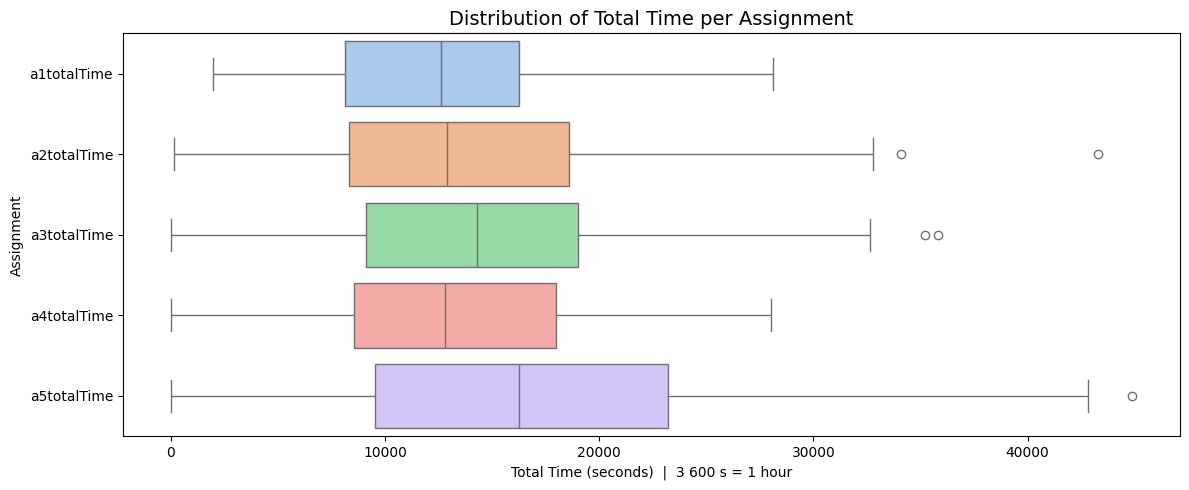

In [6]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=assignments.filter(like='totalTime'), orient='h', palette='pastel')
plt.title('Distribution of Total Time per Assignment', fontsize=14)
plt.xlabel('Total Time (seconds)  |  3 600 s = 1 hour')
plt.ylabel('Assignment')
plt.tight_layout()
plt.show()

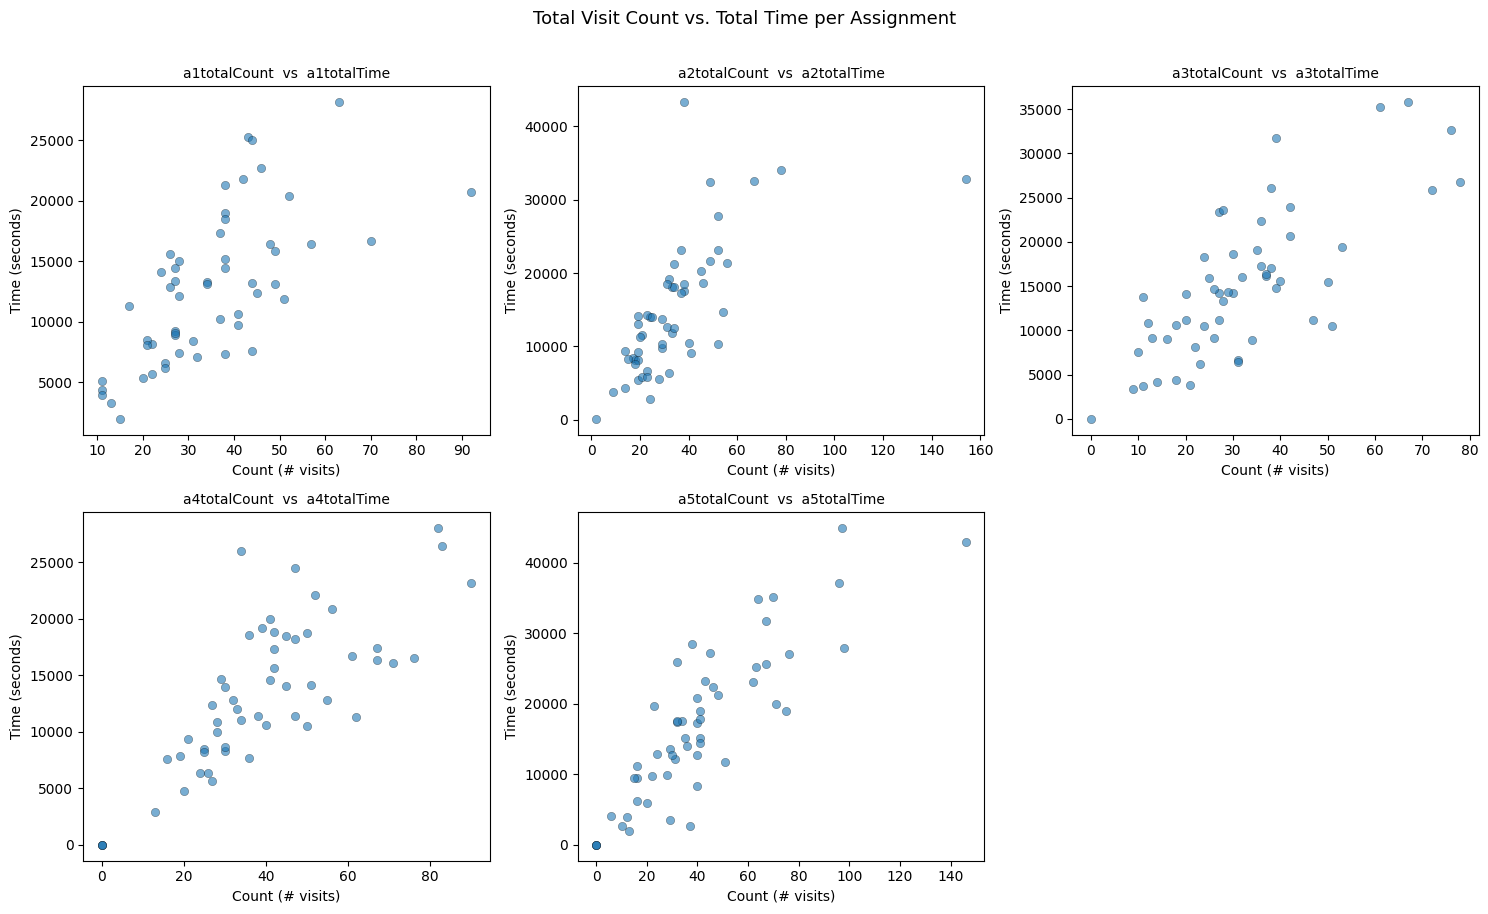

Max total time across all students/assignments: 44873 s = 12.5 hours


In [7]:
count_cols = assignments.filter(like='totalCount').columns.tolist()
n = len(count_cols)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(count_cols):
  time_col = col.replace('totalCount', 'totalTime')
  axes[i].scatter(assignments[col], assignments[time_col], alpha=0.6, edgecolors='k', linewidths=0.3)
  axes[i].set_title(f"{col}  vs  {time_col}", fontsize=10)
  axes[i].set_xlabel('Count (# visits)')
  axes[i].set_ylabel('Time (seconds)')

for j in range(n, len(axes)):
  axes[j].set_visible(False)

plt.suptitle('Total Visit Count vs. Total Time per Assignment', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
max_time = assignments.filter(like='totalTime').max().max()
print(f"Max total time across all students/assignments: {max_time:.0f} s = {max_time/3600:.1f} hours")